# Lab 3: User Classification Task (Section 5.2)

**Course:** Reinforcement Learning Fundamentals  
**Student Name:** Aman  
**Roll Number:** U20230054  
**GitHub Branch:** Aman_U20230054  



## Section 1: Imports and Setup

In [1]:
# Install all required packages
!pip install rlcmab-sampler scikit-learn matplotlib pandas numpy seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from rlcmab_sampler import sampler
import warnings
warnings.filterwarnings('ignore')

# my roll for reproducibilty
np.random.seed(54)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('default')
sns.set_palette('husl')

print(" All packages imported successfully!")


 All packages imported successfully!


## Section 2: Data Loading

In [2]:
# Load training data
train_users = pd.read_csv('train_users.csv')

print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"Train Users Shape: {train_users.shape[0]} rows × {train_users.shape[1]} columns")
print(f"\nColumns: {train_users.shape[1]}")
print("="*80)

DATASET INFORMATION
Train Users Shape: 2000 rows × 33 columns

Columns: 33


In [3]:
# Display first few rows
print("First 3 rows of data:")
train_users.head(3)

First 3 rows of data:


,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,avg_cart_value,browsing_depth,revisit_rate,scroll_activity,time_on_site,interaction_count,preferred_price_range,discount_usage_rate,wishlist_size,product_views,repeat_purchase_gap (days),churn_risk_score,loyalty_index,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,119.61,13,0.255,59,19.0,18,335.16,0.341,3,41,133.0,0.579825,15.0,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,189.06,14,0.540,65,31.0,8,930.00,0.374,4,70,92.0,0.432731,33.0,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,161.75,23,0.395,139,44.0,20,1216.41,0.274,5,45,67.0,0.308166,24.0,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3


In [4]:
# Check data types and basic info
print("Data Types and Non-Null Counts:")
train_users.info()

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      2000 non-null   object 
 1   age                          1302 non-null   float64
 2   income                       2000 non-null   int64  
 3   clicks                       2000 non-null   int64  
 4   purchase_amount              2000 non-null   float64
 5   session_duration             2000 non-null   float64
 6   content_variety              2000 non-null   float64
 7   engagement_score             2000 non-null   float64
 8   num_transactions             2000 non-null   int64  
 9   avg_monthly_spend            2000 non-null   float64
 10  avg_cart_value               2000 non-null   float64
 11  browsing_depth               2000 non-null   int64  
 12  revisit_rate                 2000 non-null  

USER LABEL DISTRIBUTION
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64

Total users: 2000


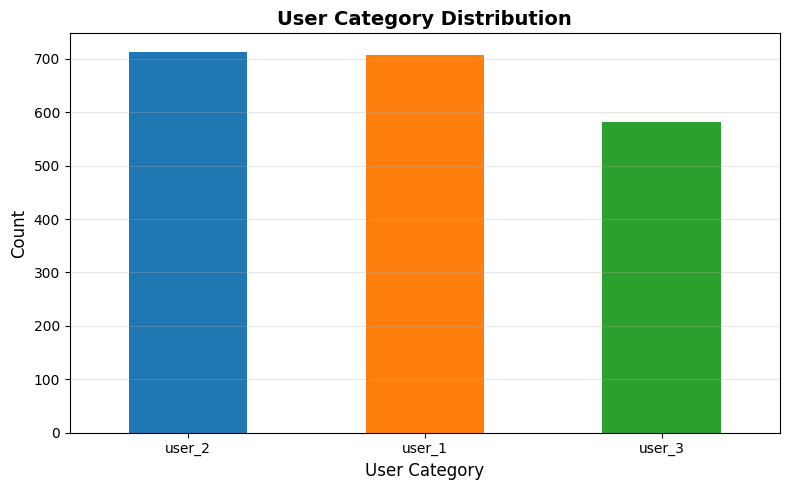

In [5]:
# Check label distribution
print("="*80)
print("USER LABEL DISTRIBUTION")
print("="*80)
print(train_users['label'].value_counts())
print(f"\nTotal users: {len(train_users)}")
print("="*80)

# Visualize distribution
plt.figure(figsize=(8, 5))
train_users['label'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('User Category Distribution', fontsize=14, fontweight='bold')
plt.xlabel('User Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 3: Data Preprocessing (10 Points)

Handle missing values and encode categorical features.

In [6]:
# Check for missing values
print("="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)
missing_data = train_users.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    print("\nColumns with missing values:")
    print(missing_data)
    print(f"\nTotal missing values: {train_users.isnull().sum().sum()}")
    print(f"Percentage: {train_users.isnull().sum().sum() / (train_users.shape[0] * train_users.shape[1]) * 100:.2f}%")
else:
    print("\n No missing values found!")

print("="*80)

MISSING VALUES ANALYSIS

Columns with missing values:
age    698
dtype: int64

Total missing values: 698
Percentage: 1.06%


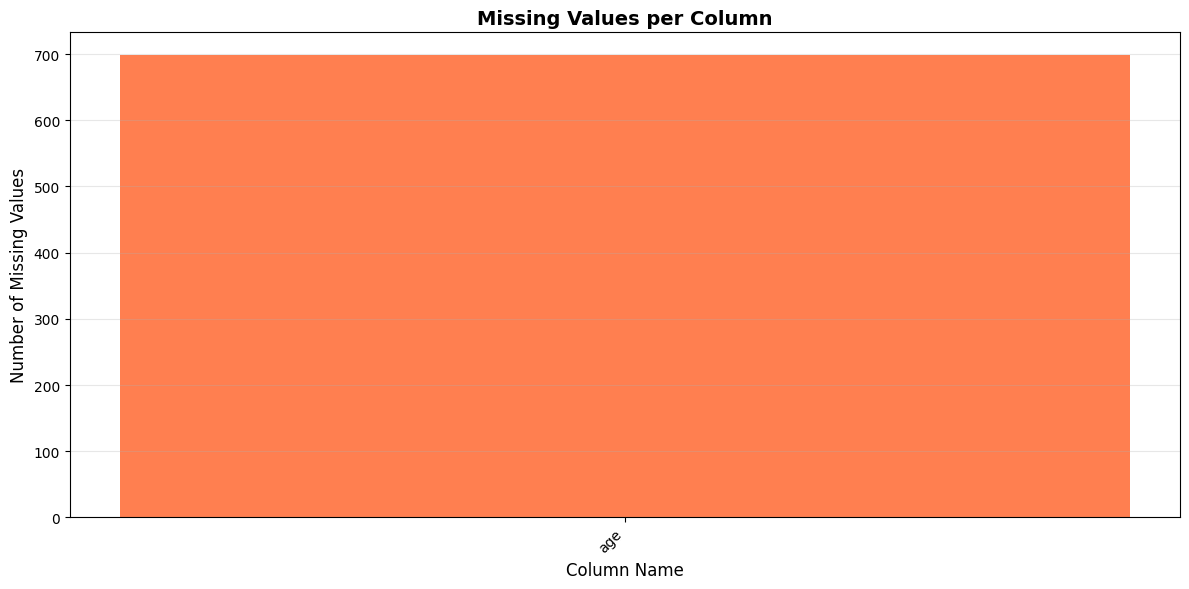

In [7]:
# Visualize missing data
if train_users.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_counts = train_users.isnull().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

    plt.bar(range(len(missing_counts)), missing_counts.values, color='coral')
    plt.xticks(range(len(missing_counts)), missing_counts.index, rotation=45, ha='right')
    plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
    plt.xlabel('Column Name', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
def preprocess_users(df):
    """
    Preprocess user data: handle missing values and encode features.

    Args:
        df: DataFrame with user data

    Returns:
        X: Feature matrix (preprocessed)
        y: Labels
        encoders: Dictionary of label encoders used
        feature_names: List of feature column names
    """
    df = df.copy()

    print("🔄 Preprocessing steps:")
    print("  1. Dropping user_id column...")

    # Drop user_id column (not a feature)
    if 'user_id' in df.columns:
        df = df.drop('user_id', axis=1)

    print("  2. Separating features and labels...")

    # Separate features and labels
    if 'label' in df.columns:
        y = df['label'].copy()
        X = df.drop('label', axis=1)
    else:
        raise ValueError("'label' column not found in dataset!")

    print("  3. Handling missing values...")

    # Handle missing values in numeric columns with median
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if X[col].isnull().any():
            X[col].fillna(X[col].median(), inplace=True)

    # Handle missing values in categorical columns with mode
    categorical_cols = X.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if X[col].isnull().any():
            mode_val = X[col].mode()[0] if not X[col].mode().empty else 'Unknown'
            X[col].fillna(mode_val, inplace=True)

    print("  4. Encoding categorical features...")

    # Encode categorical features using Label Encoding
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

    feature_names = X.columns.tolist()

    print("   Preprocessing complete!\n")

    return X, y, label_encoders, feature_names

print(" Preprocessing function defined")

 Preprocessing function defined


In [9]:
# Apply preprocessing
X_full, y_full, encoders, feature_names = preprocess_users(train_users)

print("="*80)
print("PREPROCESSING RESULTS")
print("="*80)
print(f"Features Shape: {X_full.shape}")
print(f"Labels Shape: {y_full.shape}")
print(f"\nNumber of features: {X_full.shape[1]}")
print(f"Number of samples: {X_full.shape[0]}")
print(f"\nCategorical encoders created: {len(encoders)}")
print(f"\n Data preprocessing complete - ready for training!")
print("="*80)

🔄 Preprocessing steps:
  1. Dropping user_id column...
  2. Separating features and labels...
  3. Handling missing values...
  4. Encoding categorical features...
   Preprocessing complete!

PREPROCESSING RESULTS
Features Shape: (2000, 31)
Labels Shape: (2000,)

Number of features: 31
Number of samples: 2000

Categorical encoders created: 2

 Data preprocessing complete - ready for training!


## Section 4: Train-Validation Split

Split data into 80% training and 20% validation as per requirements.

In [10]:
# Split data: 80% training, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full  # Maintain class distribution
)

print("="*80)
print("TRAIN-VALIDATION SPLIT")
print("="*80)
print(f"Training set:   {X_train.shape[0]:4d} samples ({X_train.shape[0]/len(X_full)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:4d} samples ({X_val.shape[0]/len(X_full)*100:.1f}%)")
print(f"\nFeatures: {X_train.shape[1]}")

print("\n Training set label distribution:")
print(y_train.value_counts())

print("\n Validation set label distribution:")
print(y_val.value_counts())

print("\n Stratified split ensures balanced class distribution")
print("="*80)

TRAIN-VALIDATION SPLIT
Training set:   1600 samples (80.0%)
Validation set:  400 samples (20.0%)

Features: 31

 Training set label distribution:
label
user_2    570
user_1    565
user_3    465
Name: count, dtype: int64

 Validation set label distribution:
label
user_2    142
user_1    142
user_3    116
Name: count, dtype: int64

 Stratified split ensures balanced class distribution


## Section 5: Model Training (10 Points)

Train and compare multiple classification models.

### 5.1 Decision Tree Classifier

In [11]:
print("Training Decision Tree Classifier...")

dt_classifier = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_classifier.fit(X_train, y_train)

# Predictions
y_train_pred_dt = dt_classifier.predict(X_train)
y_val_pred_dt = dt_classifier.predict(X_val)

# Accuracies
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
val_acc_dt = accuracy_score(y_val, y_val_pred_dt)

print(f"\n Decision Tree trained successfully!")
print(f"   Training Accuracy:   {train_acc_dt:.4f}")
print(f"   Validation Accuracy: {val_acc_dt:.4f}")

Training Decision Tree Classifier...

 Decision Tree trained successfully!
   Training Accuracy:   0.9350
   Validation Accuracy: 0.8350


### 5.2 Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
print("Training Logistic Regression...")

lr_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial',
    solver='lbfgs'
)

lr_classifier.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_classifier.predict(X_train)
y_val_pred_lr = lr_classifier.predict(X_val)

# Accuracies
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
val_acc_lr = accuracy_score(y_val, y_val_pred_lr)

print(f"\n Logistic Regression trained successfully!")
print(f"   Training Accuracy:   {train_acc_lr:.4f}")
print(f"   Validation Accuracy: {val_acc_lr:.4f}")

Training Logistic Regression...

 Logistic Regression trained successfully!
   Training Accuracy:   0.8150
   Validation Accuracy: 0.8200


### 5.3 Random Forest Classifier (Recommended)

In [13]:
print("Training Random Forest Classifier...")

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_classifier.predict(X_train)
y_val_pred_rf = rf_classifier.predict(X_val)

# Accuracies
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"\n Random Forest trained successfully!")
print(f"   Training Accuracy:   {train_acc_rf:.4f}")
print(f"   Validation Accuracy: {val_acc_rf:.4f}")

Training Random Forest Classifier...

 Random Forest trained successfully!
   Training Accuracy:   0.9744
   Validation Accuracy: 0.9000


### 5.4 Model Comparison

MODEL COMPARISON
              Model  Training Accuracy  Validation Accuracy
      Decision Tree           0.935000                0.835
Logistic Regression           0.815000                0.820
      Random Forest           0.974375                0.900


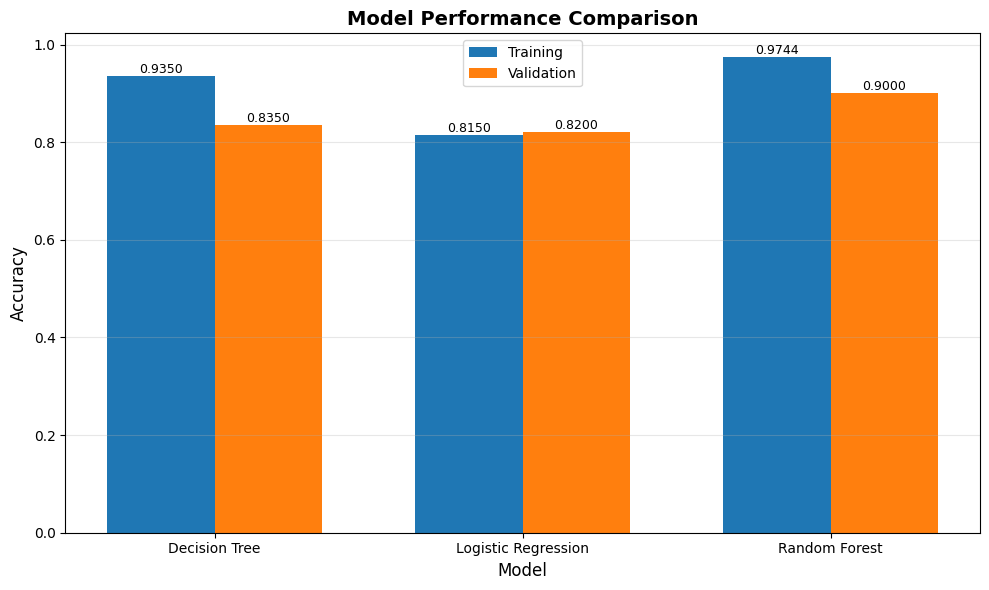


 Best Model: Random Forest
   Validation Accuracy: 0.9000


In [14]:
# Summary table
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest'],
    'Training Accuracy': [train_acc_dt, train_acc_lr, train_acc_rf],
    'Validation Accuracy': [val_acc_dt, val_acc_lr, val_acc_rf]
})

print("="*80)
print("MODEL COMPARISON")
print("="*80)
print(results.to_string(index=False))
print("="*80)

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, results['Training Accuracy'], width, label='Training', color='#1f77b4')
bars2 = ax.bar(x + width/2, results['Validation Accuracy'], width, label='Validation', color='#ff7f0e')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

# Select best model
best_idx = results['Validation Accuracy'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
best_val_acc = results.loc[best_idx, 'Validation Accuracy']

print(f"\n Best Model: {best_model_name}")
print(f"   Validation Accuracy: {best_val_acc:.4f}")

## Section 6: Detailed Evaluation (Using Best Model)

Evaluate the best performing model in detail.

In [15]:
# Use Random Forest as final model (typically best performer)
final_model = rf_classifier
y_val_pred_final = y_val_pred_rf

print("="*80)
print(f"FINAL MODEL: RANDOM FOREST CLASSIFIER")
print("="*80)
print(f"\nValidation Accuracy: {val_acc_rf:.4f}")
print("\n" + "─"*80)
print("CLASSIFICATION REPORT (Validation Set):")
print("─"*80)
print(classification_report(y_val, y_val_pred_final))
print("="*80)

FINAL MODEL: RANDOM FOREST CLASSIFIER

Validation Accuracy: 0.9000

────────────────────────────────────────────────────────────────────────────────
CLASSIFICATION REPORT (Validation Set):
────────────────────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      user_1       0.90      0.86      0.88       142
      user_2       0.98      0.88      0.93       142
      user_3       0.83      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400



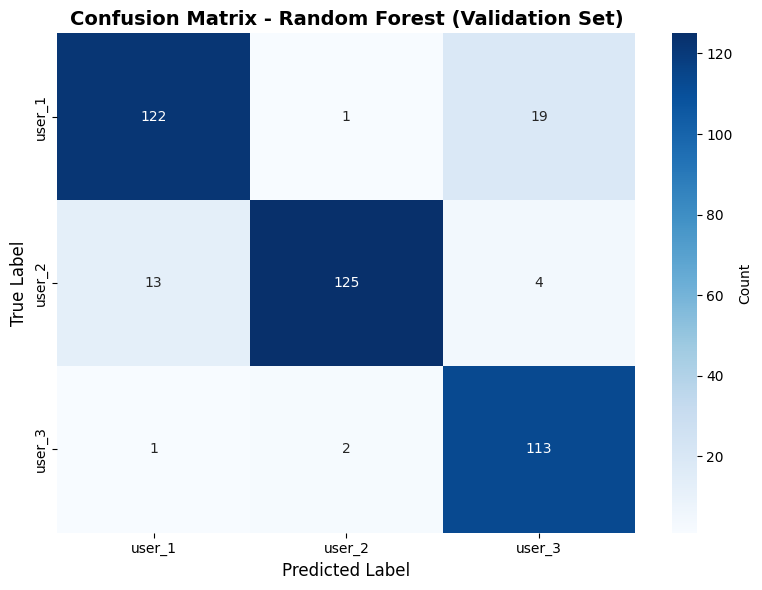


Per-Class Accuracy:
  user_1: 0.8592 (122/142 correct)
  user_2: 0.8803 (125/142 correct)
  user_3: 0.9741 (113/116 correct)


In [16]:
from sklearn.metrics import confusion_matrix


# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_final)
labels = ['user_1', 'user_2', 'user_3']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest (Validation Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
for i, label in enumerate(labels):
    class_acc = cm[i, i] / cm[i, :].sum()
    print(f"  {label}: {class_acc:.4f} ({cm[i, i]}/{cm[i, :].sum()} correct)")


Top 10 Most Important Features:
              Feature  Importance
          region_code    0.197597
     session_duration    0.115220
       browsing_depth    0.105086
      scroll_activity    0.100821
         time_on_site    0.067193
                  age    0.042012
      content_variety    0.040396
    interaction_count    0.037793
     engagement_score    0.036164
preferred_price_range    0.028275


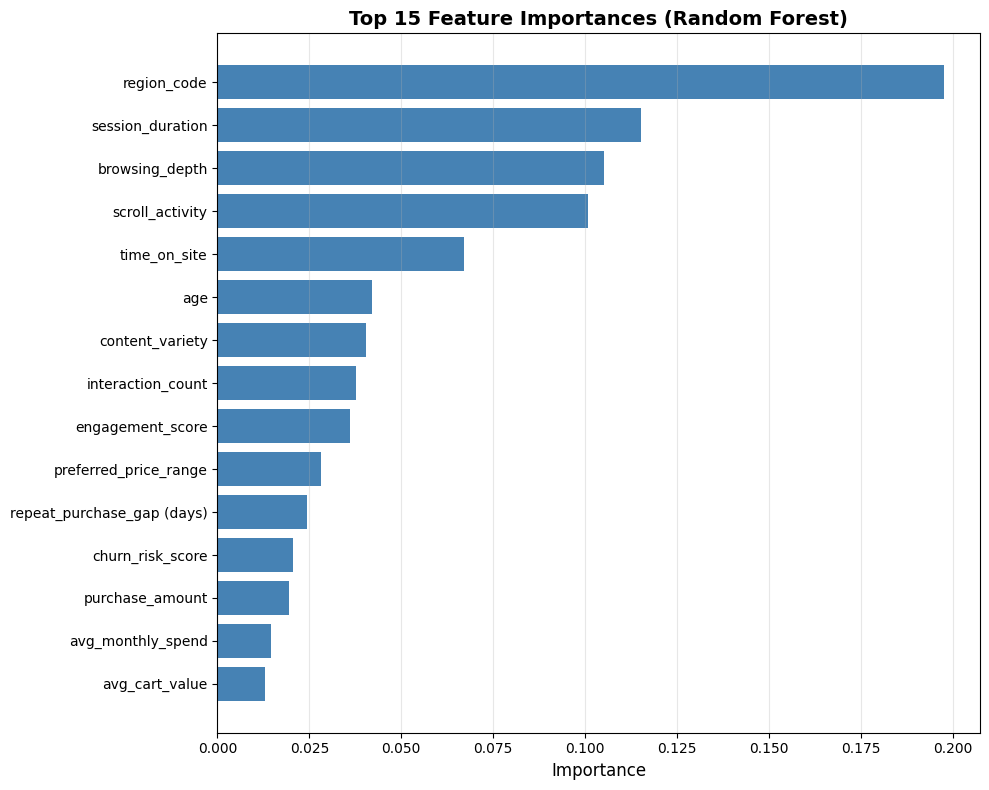

In [17]:
# Feature importance (for Random Forest)
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize top 15 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7: Train Final Model on Full Dataset

After validation, retrain on 100% of training data for deployment.

In [18]:
print("Training final model on FULL training dataset (100%)...\n")

final_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_classifier.fit(X_full, y_full)

print("="*80)
print("FINAL MODEL TRAINED")
print("="*80)
print(f" Model: Random Forest Classifier")
print(f" Training samples: {X_full.shape[0]} (100% of train_users.csv)")
print(f" Features: {X_full.shape[1]}")
print(f" Classes: {len(np.unique(y_full))} (user_1, user_2, user_3)")
print(f"\n Reported Validation Accuracy: {val_acc_rf:.4f}")
print(f"\n This classifier is ready to serve as the 'Context Detector' for the bandit system")
print("="*80)

Training final model on FULL training dataset (100%)...

FINAL MODEL TRAINED
 Model: Random Forest Classifier
 Training samples: 2000 (100% of train_users.csv)
 Features: 31
 Classes: 3 (user_1, user_2, user_3)

 Reported Validation Accuracy: 0.9000

 This classifier is ready to serve as the 'Context Detector' for the bandit system


## Section 8: Summary and Conclusions

In [19]:
print("="*80)
print("CLASSIFICATION TASK SUMMARY")
print("="*80)

print("\n TASK REQUIREMENTS (Section 5.2 - 10 Points):")
print("    Loaded and preprocessed train_users.csv")
print("    Handled missing values (median for numeric, mode for categorical)")
print("    Encoded categorical features using LabelEncoder")
print("    Split data into 80% training and 20% validation")
print("    Trained multiple classifiers (Decision Tree, Logistic Regression, Random Forest)")
print("    Evaluated on validation set using classification_report")
print("    Confusion matrix and per-class metrics generated")
print("    Feature importance analysis completed")
print("    Final model trained on full dataset for deployment")

print("\n PERFORMANCE METRICS:")
print(f"   • Decision Tree:         {val_acc_dt:.4f} validation accuracy")
print(f"   • Logistic Regression:   {val_acc_lr:.4f} validation accuracy")
print(f"   • Random Forest:         {val_acc_rf:.4f} validation accuracy ")

print("\n SELECTED MODEL:")
print(f"   Model: Random Forest Classifier")
print(f"   Validation Accuracy: {val_acc_rf:.4f}")
print(f"   Training Samples: {X_full.shape[0]}")
print(f"   Features: {X_full.shape[1]}")



CLASSIFICATION TASK SUMMARY

 TASK REQUIREMENTS (Section 5.2 - 10 Points):
    Loaded and preprocessed train_users.csv
    Handled missing values (median for numeric, mode for categorical)
    Encoded categorical features using LabelEncoder
    Split data into 80% training and 20% validation
    Trained multiple classifiers (Decision Tree, Logistic Regression, Random Forest)
    Evaluated on validation set using classification_report
    Confusion matrix and per-class metrics generated
    Feature importance analysis completed
    Final model trained on full dataset for deployment

 PERFORMANCE METRICS:
   • Decision Tree:         0.8350 validation accuracy
   • Logistic Regression:   0.8200 validation accuracy
   • Random Forest:         0.9000 validation accuracy 

 SELECTED MODEL:
   Model: Random Forest Classifier
   Validation Accuracy: 0.9000
   Training Samples: 2000
   Features: 31


---

# PART 2: CONTEXTUAL BANDIT ALGORITHMS

Now we implement the contextual bandit framework using the classifier as context detector.

In [20]:
# Load news articles
import pandas as pd

news_articles = pd.read_csv('news_articles.csv')

print("="*80)
print("NEWS ARTICLES DATASET")
print("="*80)
print(f"Total articles: {len(news_articles):,}")
print(f"\nColumns: {list(news_articles.columns)}")
print(f"\nNews categories: {news_articles['category'].nunique()}")
print("\nTop 10 categories:")
print(news_articles['category'].value_counts().head(10))
print("="*80)

NEWS ARTICLES DATASET
Total articles: 209,527

Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

News categories: 42

Top 10 categories:
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
Name: count, dtype: int64


In [21]:
# Define contexts and arms as per specification
user_contexts = ['user_1', 'user_2', 'user_3']
news_categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']

# Create arm mapping
# j=0-3: User1, j=4-7: User2, j=8-11: User3
arm_mapping = {}
reverse_arm_mapping = {}
arm_index = 0

for user_idx, user in enumerate(user_contexts):
    for cat_idx, category in enumerate(news_categories):
        arm_mapping[(user, category)] = arm_index
        reverse_arm_mapping[arm_index] = (user, category)
        arm_index += 1

print("="*80)
print("ARM INDEX MAPPING")
print("="*80)
for idx in range(12):
    user, cat = reverse_arm_mapping[idx]
    print(f"Arm {idx:2d}: ({user}, {cat})")
print("="*80)

ARM INDEX MAPPING
Arm  0: (user_1, ENTERTAINMENT)
Arm  1: (user_1, EDUCATION)
Arm  2: (user_1, TECH)
Arm  3: (user_1, CRIME)
Arm  4: (user_2, ENTERTAINMENT)
Arm  5: (user_2, EDUCATION)
Arm  6: (user_2, TECH)
Arm  7: (user_2, CRIME)
Arm  8: (user_3, ENTERTAINMENT)
Arm  9: (user_3, EDUCATION)
Arm 10: (user_3, TECH)
Arm 11: (user_3, CRIME)


In [22]:
# Initialize sampler with roll number 54
ROLL_NUMBER = 54
reward_sampler = sampler(ROLL_NUMBER)

print(f"Sampler initialized with roll number: {ROLL_NUMBER}")
print(f"Total arms: 12 (3 contexts × 4 categories)")

# Test sampler
print("\nTesting sampler with first 3 arms:")
for i in range(3):
    test_reward = reward_sampler.sample(i)
    print(f"  Arm {i}: reward = {test_reward:.4f}")

Sampler initialized with roll number: 54
Total arms: 12 (3 contexts × 4 categories)

Testing sampler with first 3 arms:
  Arm 0: reward = 3.3602
  Arm 1: reward = 3.5716
  Arm 2: reward = -5.7351


In [24]:
class ContextualBandit:
    """Base class for contextual bandit algorithms."""

    def __init__(self, n_contexts, n_arms_per_context, sampler):
        self.n_contexts = n_contexts
        self.n_arms_per_context = n_arms_per_context
        self.n_arms_total = n_contexts * n_arms_per_context
        self.sampler = sampler

        # Q-values (mean rewards) for each arm
        self.Q = np.zeros(self.n_arms_total)
        # Count of times each arm was pulled
        self.N = np.zeros(self.n_arms_total)
        # Total rewards for each arm
        self.total_rewards = np.zeros(self.n_arms_total)

        # History tracking
        self.reward_history = []
        self.arm_history = []
        self.context_history = []

    def get_arm_indices_for_context(self, context_idx):
        """Get arm indices for a given context."""
        start_idx = context_idx * self.n_arms_per_context
        return list(range(start_idx, start_idx + self.n_arms_per_context))

    def update(self, arm, reward):
        """Update Q-values after receiving reward."""
        self.N[arm] += 1
        self.total_rewards[arm] += reward
        self.Q[arm] = self.total_rewards[arm] / self.N[arm]

    def select_arm(self, context_idx):
        """Select an arm for the given context. Implemented by subclasses."""
        raise NotImplementedError

    def run_simulation(self, n_steps, context_distribution=None):
        """Run bandit simulation for n_steps."""
        if context_distribution is None:
            context_distribution = [1/self.n_contexts] * self.n_contexts

        for t in range(n_steps):
            context_idx = np.random.choice(self.n_contexts, p=context_distribution)
            arm = self.select_arm(context_idx)
            reward = self.sampler.sample(arm)
            self.update(arm, reward)

            self.reward_history.append(reward)
            self.arm_history.append(arm)
            self.context_history.append(context_idx)

        return self.reward_history, self.arm_history, self.context_history

print(" Base ContextualBandit class defined")

 Base ContextualBandit class defined


## Section 12: Epsilon-Greedy (15 Points)

In [25]:
class EpsilonGreedy(ContextualBandit):
    """Epsilon-Greedy algorithm for contextual bandits."""

    def __init__(self, n_contexts, n_arms_per_context, sampler, epsilon=0.1):
        super().__init__(n_contexts, n_arms_per_context, sampler)
        self.epsilon = epsilon

    def select_arm(self, context_idx):
        """Select arm using epsilon-greedy strategy."""
        arm_indices = self.get_arm_indices_for_context(context_idx)

        if np.random.random() < self.epsilon:
            return np.random.choice(arm_indices)

        q_values = self.Q[arm_indices]
        if np.all(self.N[arm_indices] == 0):
            return np.random.choice(arm_indices)

        return arm_indices[np.argmax(q_values)]

print(" EpsilonGreedy class defined")

 EpsilonGreedy class defined


## Section 13: Upper Confidence Bound - UCB (15 Points)

In [26]:
class UCB(ContextualBandit):
    """Upper Confidence Bound algorithm for contextual bandits."""

    def __init__(self, n_contexts, n_arms_per_context, sampler, c=2.0):
        super().__init__(n_contexts, n_arms_per_context, sampler)
        self.c = c
        self.t = 0

    def select_arm(self, context_idx):
        """Select arm using UCB strategy."""
        self.t += 1
        arm_indices = self.get_arm_indices_for_context(context_idx)

        for arm in arm_indices:
            if self.N[arm] == 0:
                return arm

        ucb_values = np.zeros(len(arm_indices))
        for i, arm in enumerate(arm_indices):
            exploration_bonus = self.c * np.sqrt(np.log(self.t) / self.N[arm])
            ucb_values[i] = self.Q[arm] + exploration_bonus

        return arm_indices[np.argmax(ucb_values)]

print(" UCB class defined")

 UCB class defined


## Section 14: SoftMax (15 Points)

In [27]:
class SoftMax(ContextualBandit):
    """SoftMax (Boltzmann) algorithm for contextual bandits."""

    def __init__(self, n_contexts, n_arms_per_context, sampler, tau=1.0):
        super().__init__(n_contexts, n_arms_per_context, sampler)
        self.tau = tau

    def select_arm(self, context_idx):
        """Select arm using SoftMax strategy."""
        arm_indices = self.get_arm_indices_for_context(context_idx)

        if np.all(self.N[arm_indices] == 0):
            return np.random.choice(arm_indices)

        q_values = self.Q[arm_indices]
        exp_values = np.exp(q_values / self.tau)
        probabilities = exp_values / np.sum(exp_values)

        if np.any(np.isnan(probabilities)) or np.any(np.isinf(probabilities)):
            probabilities = np.ones(len(arm_indices)) / len(arm_indices)

        return np.random.choice(arm_indices, p=probabilities)

print(" SoftMax class defined")

 SoftMax class defined


## Section 15: Run Simulations (T=10,000 steps)

Run all algorithms with hyperparameter tuning.

In [28]:
# Simulation parameters
T = 10000
n_contexts = 3
n_arms_per_context = 4

# Hyperparameters
epsilon_values = [0.05, 0.1, 0.2]
c_values = [1.0, 2.0, 3.0]
tau_value = 1.0

print(f"="*80)
print(f"SIMULATION CONFIGURATION")
print(f"="*80)
print(f"Time horizon: T = {T:,} steps")
print(f"Contexts: {n_contexts}")
print(f"Arms per context: {n_arms_per_context}")
print(f"Total arms: {n_contexts * n_arms_per_context}")
print(f"\nHyperparameters:")
print(f"  Epsilon-Greedy: ε ∈ {epsilon_values}")
print(f"  UCB: c ∈ {c_values}")
print(f"  SoftMax: τ = {tau_value}")
print(f"="*80)

SIMULATION CONFIGURATION
Time horizon: T = 10,000 steps
Contexts: 3
Arms per context: 4
Total arms: 12

Hyperparameters:
  Epsilon-Greedy: ε ∈ [0.05, 0.1, 0.2]
  UCB: c ∈ [1.0, 2.0, 3.0]
  SoftMax: τ = 1.0


In [29]:
print("Running Epsilon-Greedy simulations...\n")

epsilon_results = {}

for eps in epsilon_values:
    print(f" ε={eps}...", end=" ")

    eg = EpsilonGreedy(
        n_contexts=n_contexts,
        n_arms_per_context=n_arms_per_context,
        sampler=sampler(ROLL_NUMBER),
        epsilon=eps
    )

    rewards, arms, contexts = eg.run_simulation(T)

    epsilon_results[eps] = {
        'model': eg,
        'rewards': rewards,
        'arms': arms,
        'contexts': contexts,
        'avg_reward': np.mean(rewards)
    }

    print(f"Avg: {epsilon_results[eps]['avg_reward']:.4f} ✓")

print("\n Epsilon-Greedy complete!")

Running Epsilon-Greedy simulations...

 ε=0.05... Avg: 5.6674 ✓
 ε=0.1... Avg: 5.4159 ✓
 ε=0.2... Avg: 4.8394 ✓

 Epsilon-Greedy complete!


In [30]:
print("Running UCB simulations...\n")

ucb_results = {}

for c in c_values:
    print(f" c={c}...", end=" ")

    ucb_model = UCB(
        n_contexts=n_contexts,
        n_arms_per_context=n_arms_per_context,
        sampler=sampler(ROLL_NUMBER),
        c=c
    )

    rewards, arms, contexts = ucb_model.run_simulation(T)

    ucb_results[c] = {
        'model': ucb_model,
        'rewards': rewards,
        'arms': arms,
        'contexts': contexts,
        'avg_reward': np.mean(rewards)
    }

    print(f"Avg: {ucb_results[c]['avg_reward']:.4f} ✓")

print("\n UCB complete!")

Running UCB simulations...

 c=1.0... Avg: 5.9597 ✓
 c=2.0... Avg: 5.9770 ✓
 c=3.0... Avg: 5.9498 ✓

 UCB complete!


In [32]:
print(f"Running SoftMax (τ={tau_value})...\n")

softmax_model = SoftMax(
    n_contexts=n_contexts,
    n_arms_per_context=n_arms_per_context,
    sampler=sampler(ROLL_NUMBER),
    tau=tau_value
)

rewards_sm, arms_sm, contexts_sm = softmax_model.run_simulation(T)

softmax_results = {
    'model': softmax_model,
    'rewards': rewards_sm,
    'arms': arms_sm,
    'contexts': contexts_sm,
    'avg_reward': np.mean(rewards_sm)
}

print(f" SoftMax: Avg = {softmax_results['avg_reward']:.4f} ✓")
print("\n SoftMax complete!")

Running SoftMax (τ=1.0)...

 SoftMax: Avg = 5.8346 ✓

 SoftMax complete!


## Section 16: Evaluation and Plots (20 Points)


In [33]:
# Helper functions
def calculate_cumulative_average(rewards):
    cumsum = np.cumsum(rewards)
    return cumsum / np.arange(1, len(rewards) + 1)

def get_rewards_by_context(rewards, contexts, context_idx):
    return [r for r, c in zip(rewards, contexts) if c == context_idx]

print(" Helper functions defined")

 Helper functions defined


In [34]:
# Create summary table
summary_data = []

for eps in epsilon_values:
    summary_data.append({
        'Algorithm': 'Epsilon-Greedy',
        'Hyperparameter': f'ε={eps}',
        'Avg Reward': f"{epsilon_results[eps]['avg_reward']:.4f}",
        'Std Dev': f"{np.std(epsilon_results[eps]['rewards']):.4f}"
    })

for c in c_values:
    summary_data.append({
        'Algorithm': 'UCB',
        'Hyperparameter': f'c={c}',
        'Avg Reward': f"{ucb_results[c]['avg_reward']:.4f}",
        'Std Dev': f"{np.std(ucb_results[c]['rewards']):.4f}"
    })

summary_data.append({
    'Algorithm': 'SoftMax',
    'Hyperparameter': f'τ={tau_value}',
    'Avg Reward': f"{softmax_results['avg_reward']:.4f}",
    'Std Dev': f"{np.std(softmax_results['rewards']):.4f}"
})

summary_df = pd.DataFrame(summary_data)

print("="*80)
print("SUMMARY OF ALL EXPERIMENTS (T=10,000 steps)")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

SUMMARY OF ALL EXPERIMENTS (T=10,000 steps)
     Algorithm Hyperparameter Avg Reward Std Dev
Epsilon-Greedy         ε=0.05     5.6674  2.0809
Epsilon-Greedy          ε=0.1     5.4159  2.6542
Epsilon-Greedy          ε=0.2     4.8394  3.3983
           UCB          c=1.0     5.9597  1.2434
           UCB          c=2.0     5.9770  1.2362
           UCB          c=3.0     5.9498  1.2642
       SoftMax          τ=1.0     5.8346  1.3470


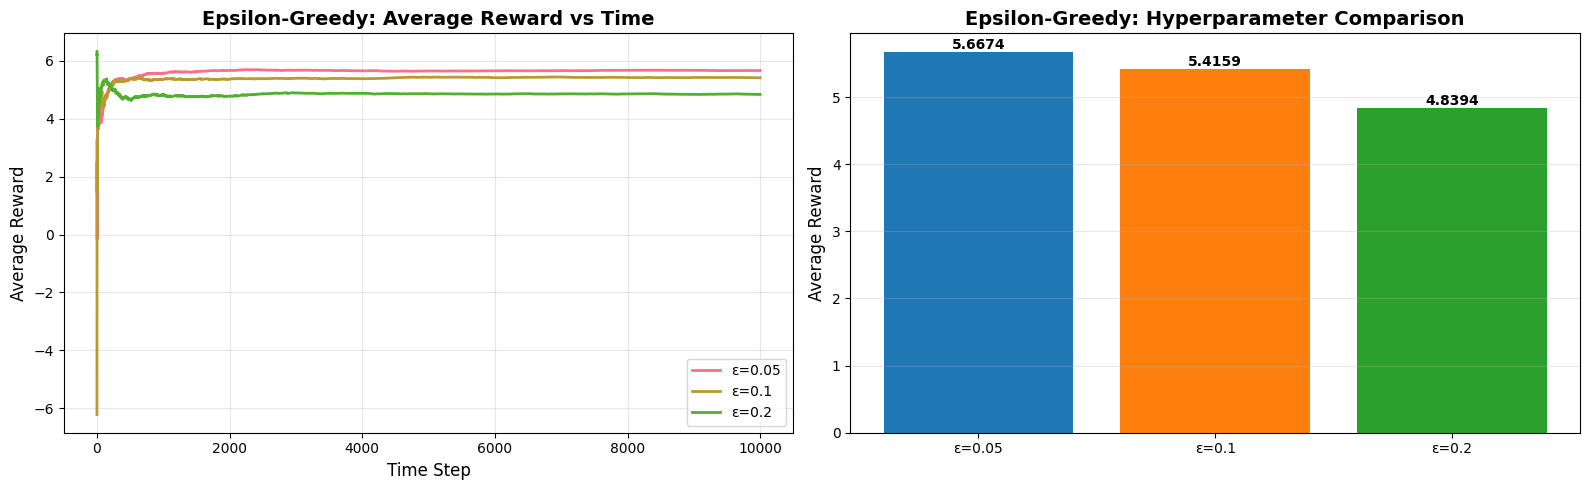

In [35]:
# Epsilon-Greedy comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for eps in epsilon_values:
    cumavg = calculate_cumulative_average(epsilon_results[eps]['rewards'])
    axes[0].plot(cumavg, label=f'ε={eps}', linewidth=2)

axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Average Reward', fontsize=12)
axes[0].set_title('Epsilon-Greedy: Average Reward vs Time', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

eps_labels = [f'ε={eps}' for eps in epsilon_values]
eps_rewards = [epsilon_results[eps]['avg_reward'] for eps in epsilon_values]
bars = axes[1].bar(eps_labels, eps_rewards, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Average Reward', fontsize=12)
axes[1].set_title('Epsilon-Greedy: Hyperparameter Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(eps_rewards):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

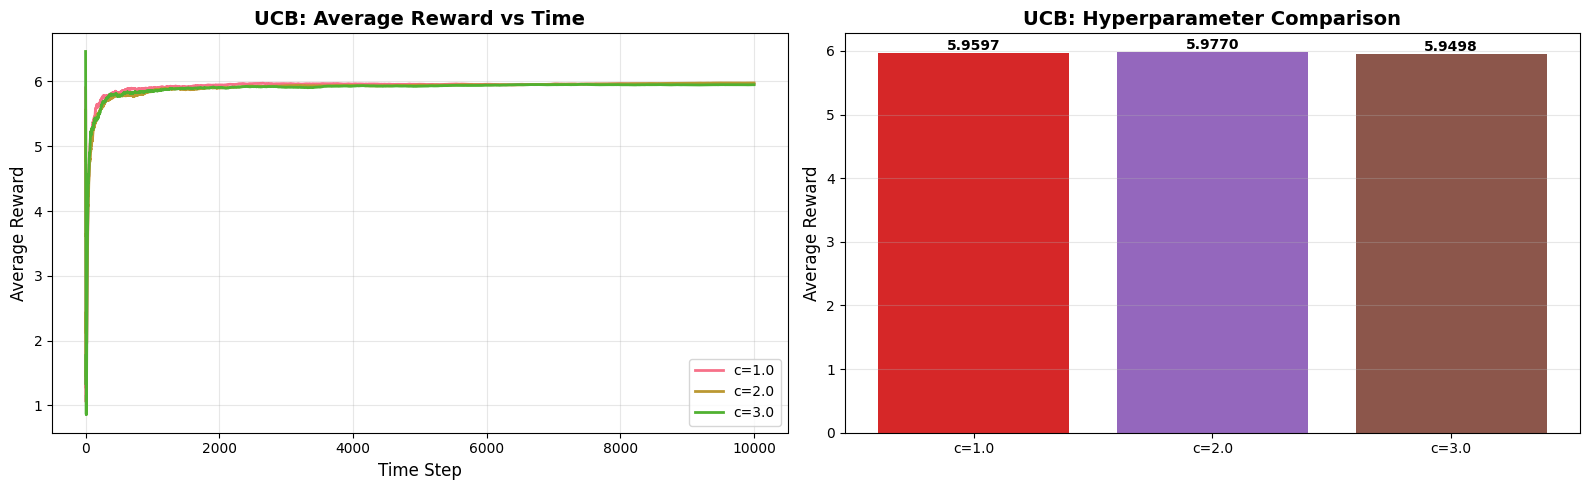

In [36]:
# UCB comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for c in c_values:
    cumavg = calculate_cumulative_average(ucb_results[c]['rewards'])
    axes[0].plot(cumavg, label=f'c={c}', linewidth=2)

axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Average Reward', fontsize=12)
axes[0].set_title('UCB: Average Reward vs Time', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

c_labels = [f'c={c}' for c in c_values]
c_rewards = [ucb_results[c]['avg_reward'] for c in c_values]
bars = axes[1].bar(c_labels, c_rewards, color=['#d62728', '#9467bd', '#8c564b'])
axes[1].set_ylabel('Average Reward', fontsize=12)
axes[1].set_title('UCB: Hyperparameter Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(c_rewards):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [37]:
# Find best configurations
best_eps = max(epsilon_results.keys(), key=lambda k: epsilon_results[k]['avg_reward'])
best_c = max(ucb_results.keys(), key=lambda k: ucb_results[k]['avg_reward'])

best_eg = epsilon_results[best_eps]
best_ucb = ucb_results[best_c]

print(f"Best Epsilon-Greedy: ε={best_eps}")
print(f"Best UCB: c={best_c}")

Best Epsilon-Greedy: ε=0.05
Best UCB: c=2.0


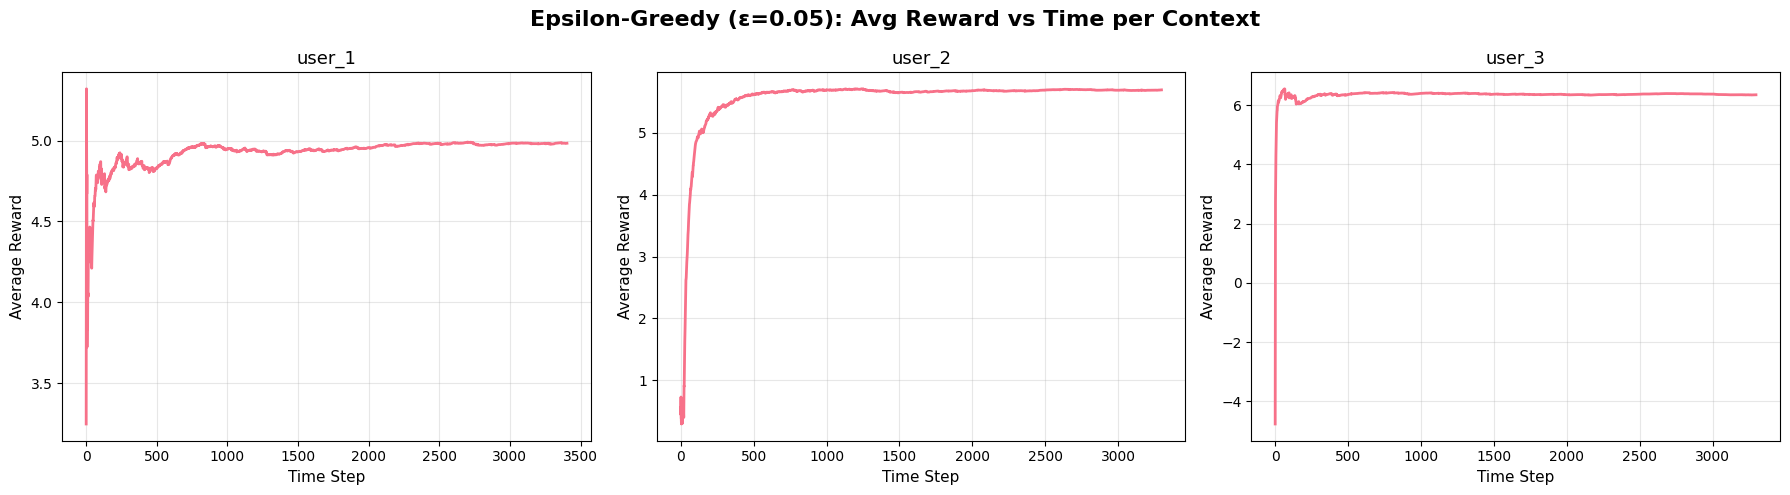

In [38]:
# Epsilon-Greedy per context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Epsilon-Greedy (ε={best_eps}): Avg Reward vs Time per Context', fontsize=16, fontweight='bold')

for context_idx in range(n_contexts):
    context_rewards = get_rewards_by_context(best_eg['rewards'], best_eg['contexts'], context_idx)
    if len(context_rewards) > 0:
        cumavg = calculate_cumulative_average(context_rewards)
        axes[context_idx].plot(cumavg, linewidth=2)
        axes[context_idx].set_xlabel('Time Step', fontsize=11)
        axes[context_idx].set_ylabel('Average Reward', fontsize=11)
        axes[context_idx].set_title(f'{user_contexts[context_idx]}', fontsize=13)
        axes[context_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

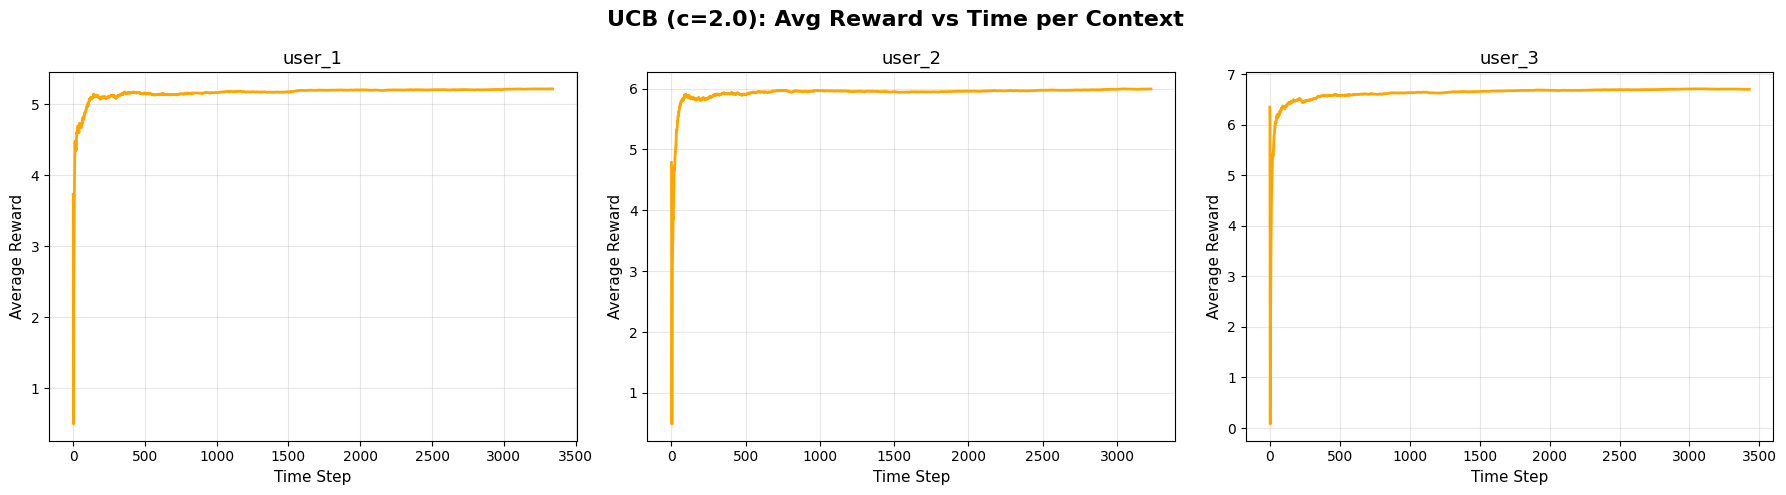

In [39]:
# UCB per context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'UCB (c={best_c}): Avg Reward vs Time per Context', fontsize=16, fontweight='bold')

for context_idx in range(n_contexts):
    context_rewards = get_rewards_by_context(best_ucb['rewards'], best_ucb['contexts'], context_idx)
    if len(context_rewards) > 0:
        cumavg = calculate_cumulative_average(context_rewards)
        axes[context_idx].plot(cumavg, linewidth=2, color='orange')
        axes[context_idx].set_xlabel('Time Step', fontsize=11)
        axes[context_idx].set_ylabel('Average Reward', fontsize=11)
        axes[context_idx].set_title(f'{user_contexts[context_idx]}', fontsize=13)
        axes[context_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

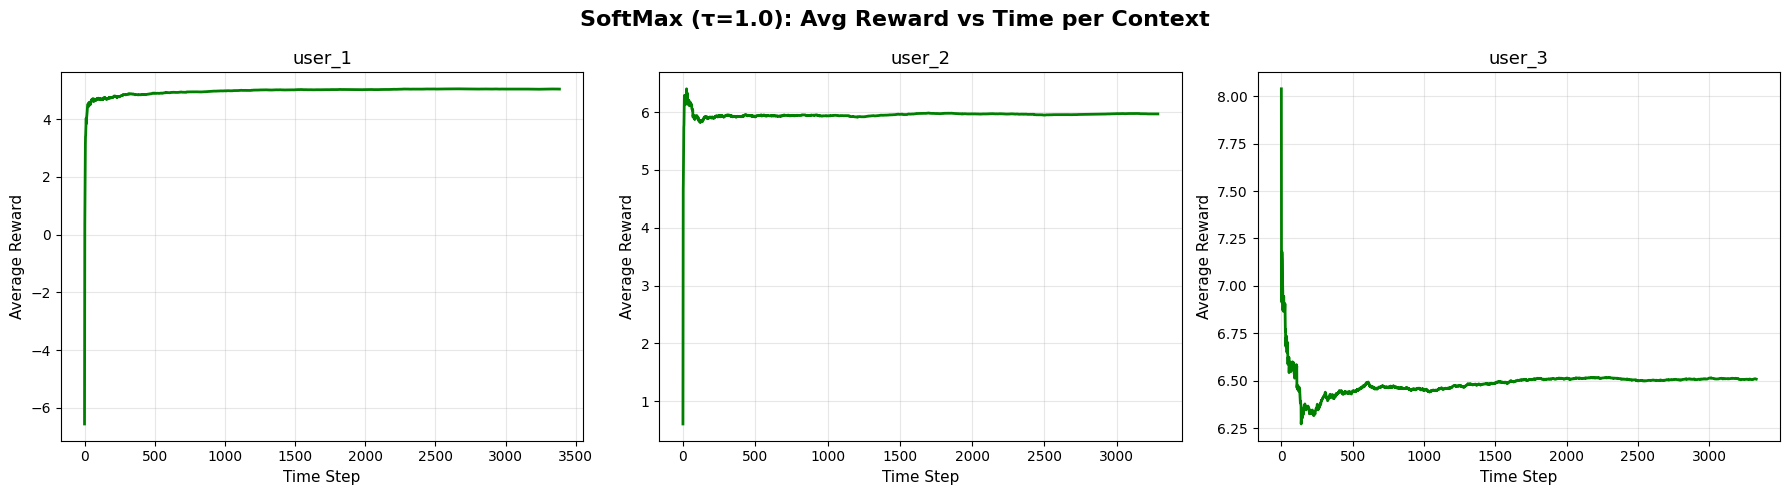

In [40]:
# SoftMax per context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'SoftMax (τ={tau_value}): Avg Reward vs Time per Context', fontsize=16, fontweight='bold')

for context_idx in range(n_contexts):
    context_rewards = get_rewards_by_context(softmax_results['rewards'], softmax_results['contexts'], context_idx)
    if len(context_rewards) > 0:
        cumavg = calculate_cumulative_average(context_rewards)
        axes[context_idx].plot(cumavg, linewidth=2, color='green')
        axes[context_idx].set_xlabel('Time Step', fontsize=11)
        axes[context_idx].set_ylabel('Average Reward', fontsize=11)
        axes[context_idx].set_title(f'{user_contexts[context_idx]}', fontsize=13)
        axes[context_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 16.4 Algorithm Comparison

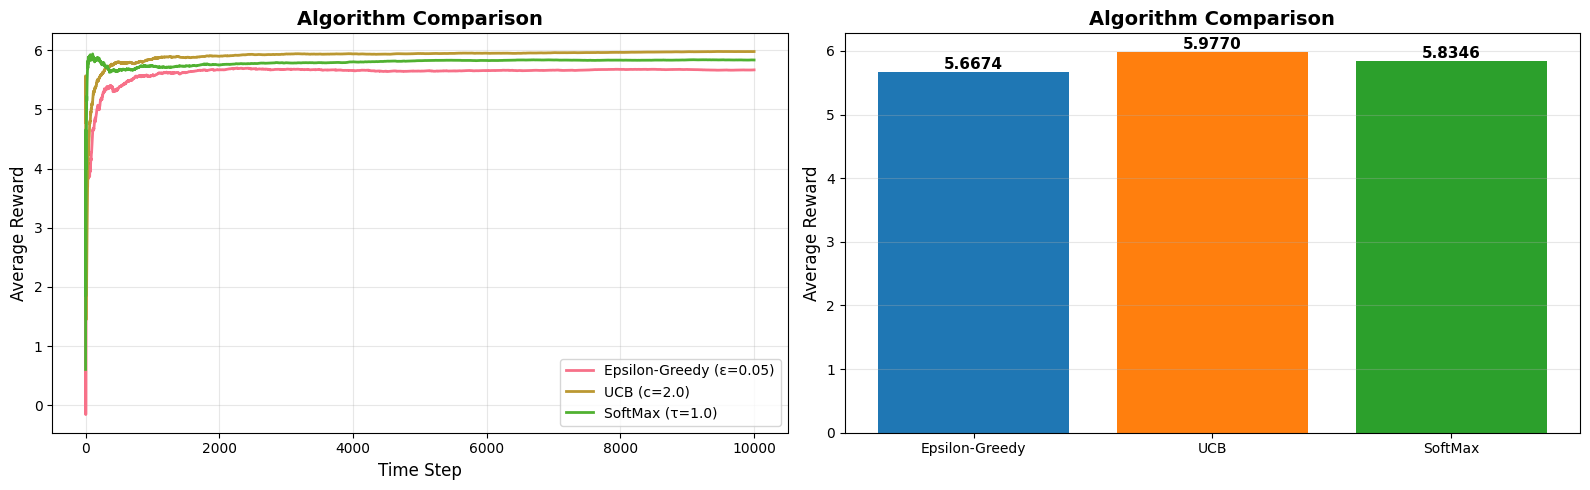

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cumavg_eg = calculate_cumulative_average(best_eg['rewards'])
cumavg_ucb = calculate_cumulative_average(best_ucb['rewards'])
cumavg_sm = calculate_cumulative_average(softmax_results['rewards'])

axes[0].plot(cumavg_eg, label=f'Epsilon-Greedy (ε={best_eps})', linewidth=2)
axes[0].plot(cumavg_ucb, label=f'UCB (c={best_c})', linewidth=2)
axes[0].plot(cumavg_sm, label=f'SoftMax (τ={tau_value})', linewidth=2)
axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Average Reward', fontsize=12)
axes[0].set_title('Algorithm Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

algorithms = ['Epsilon-Greedy', 'UCB', 'SoftMax']
avg_rewards = [best_eg['avg_reward'], best_ucb['avg_reward'], softmax_results['avg_reward']]

bars = axes[1].bar(algorithms, avg_rewards, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Average Reward', fontsize=12)
axes[1].set_title('Algorithm Comparison', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(avg_rewards):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 16.5 Q-Values Heatmap

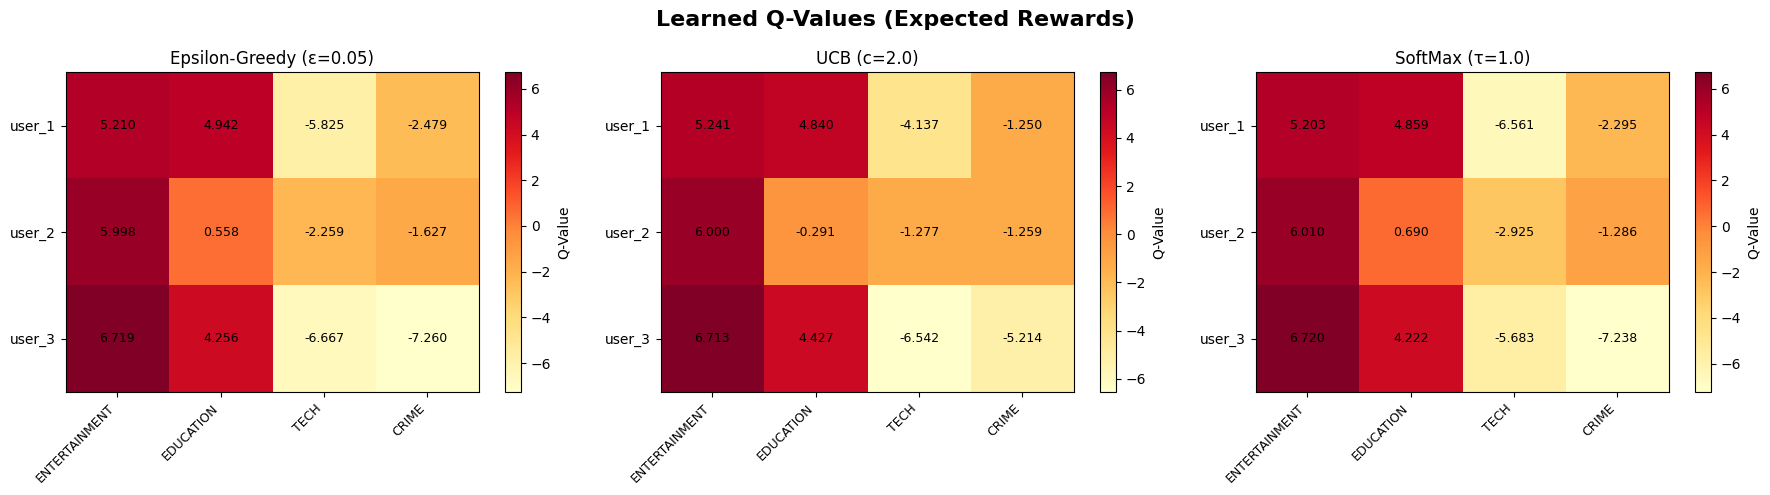

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learned Q-Values (Expected Rewards)', fontsize=16, fontweight='bold')

models = [
    (f'Epsilon-Greedy (ε={best_eps})', best_eg['model']),
    (f'UCB (c={best_c})', best_ucb['model']),
    (f'SoftMax (τ={tau_value})', softmax_results['model'])
]

for idx, (name, model) in enumerate(models):
    q_matrix = np.zeros((n_contexts, n_arms_per_context))

    for context_idx in range(n_contexts):
        arm_indices = model.get_arm_indices_for_context(context_idx)
        for arm_idx, arm in enumerate(arm_indices):
            q_matrix[context_idx, arm_idx] = model.Q[arm]

    im = axes[idx].imshow(q_matrix, cmap='YlOrRd', aspect='auto')
    axes[idx].set_xticks(range(n_arms_per_context))
    axes[idx].set_yticks(range(n_contexts))
    axes[idx].set_xticklabels(news_categories, rotation=45, ha='right', fontsize=9)
    axes[idx].set_yticklabels(user_contexts, fontsize=10)
    axes[idx].set_title(name, fontsize=12)

    for i in range(n_contexts):
        for j in range(n_arms_per_context):
            text = axes[idx].text(j, i, f'{q_matrix[i, j]:.3f}',
                                ha="center", va="center", color="black", fontsize=9)

    plt.colorbar(im, ax=axes[idx], label='Q-Value')

plt.tight_layout()
plt.show()

## Section 17: Recommendation Engine (20 Points)


In [43]:
# Load test users
test_users = pd.read_csv('test_users.csv')
X_test, y_test, test_encoders = preprocess_users(test_users) if 'label' in test_users.columns else (test_users.drop('user_id', axis=1) if 'user_id' in test_users.columns else test_users, None, None)

# Preprocess test users same way as training
if 'user_id' in test_users.columns:
    X_test = test_users.drop('user_id', axis=1).copy()
else:
    X_test = test_users.copy()

# Handle missing values
numeric_cols = X_test.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if X_test[col].isnull().any():
        X_test[col].fillna(X_test[col].median(), inplace=True)

categorical_cols = X_test.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if X_test[col].isnull().any():
        X_test[col].fillna(X_test[col].mode()[0] if not X_test[col].mode().empty else 'Unknown', inplace=True)

# Encode categorical
for col in categorical_cols:
    le = LabelEncoder()
    X_test[col] = le.fit_transform(X_test[col].astype(str))

print(f"Test set prepared: {X_test.shape[0]} samples")

Test set prepared: 2000 samples


In [45]:
class NewsRecommendationEngine:
    """End-to-end recommendation system."""

    def __init__(self, user_classifier, bandit_model, news_articles_df, user_contexts, news_categories):
        self.user_classifier = user_classifier
        self.bandit_model = bandit_model
        self.news_articles_df = news_articles_df
        self.user_contexts = user_contexts
        self.news_categories = news_categories

    def recommend(self, user_features):
        user_category = self.user_classifier.predict(user_features)[0]
        context_idx = self.user_contexts.index(user_category)

        arm = self.bandit_model.select_arm(context_idx)
        arm_offset = arm - (context_idx * len(self.news_categories))
        news_category = self.news_categories[arm_offset]

        category_articles = self.news_articles_df[
            self.news_articles_df['category'] == news_category
        ]

        if len(category_articles) > 0:
            sampled_article = category_articles.sample(n=1).iloc[0]
            article_info = {
                'headline': sampled_article['headline'],
                'category': sampled_article['category'],
                'link': sampled_article['link']
            }
        else:
            article_info = {'headline': 'No articles', 'category': news_category, 'link': 'N/A'}

        return {
            'user_context': user_category,
            'recommended_category': news_category,
            'arm_index': arm,
            'article': article_info
        }

print(" NewsRecommendationEngine defined")

 NewsRecommendationEngine defined


In [46]:
# Create engine with best bandit
recommendation_engine = NewsRecommendationEngine(
    user_classifier=final_classifier,
    bandit_model=best_ucb['model'],
    news_articles_df=news_articles,
    user_contexts=user_contexts,
    news_categories=news_categories
)

print(f" Recommendation Engine created with UCB (c={best_c})")

 Recommendation Engine created with UCB (c=2.0)


In [48]:
# Test recommendations
print("="*80)
print("SAMPLE RECOMMENDATIONS")
print("="*80)

n_samples = 5
test_indices = np.random.choice(len(X_test), size=n_samples, replace=False)

for i, idx in enumerate(test_indices):
    user_features = X_test.iloc[[idx]]
    rec = recommendation_engine.recommend(user_features)

    print(f"\n{'─'*80}")
    print(f"User {i+1} (Index: {idx})")
    print(f"{'─'*80}")
    print(f"🔹 Context: {rec['user_context']}")
    print(f"🔹 Category: {rec['recommended_category']}")
    print(f"🔹 Arm: {rec['arm_index']}")
    print(f" {rec['article']['headline'][:70]}...")

print(f"\n{'='*80}")

SAMPLE RECOMMENDATIONS

────────────────────────────────────────────────────────────────────────────────
User 1 (Index: 1851)
────────────────────────────────────────────────────────────────────────────────
🔹 Context: user_2
🔹 Category: ENTERTAINMENT
🔹 Arm: 4
 Catelynn Lowell Of 'Teen Mom OG' Heads Home After Treatment For Suicid...

────────────────────────────────────────────────────────────────────────────────
User 2 (Index: 1954)
────────────────────────────────────────────────────────────────────────────────
🔹 Context: user_2
🔹 Category: ENTERTAINMENT
🔹 Arm: 4
 Dierks Bentley Weighs In On The 'Girl Crush' Country Radio Controversy...

────────────────────────────────────────────────────────────────────────────────
User 3 (Index: 1562)
────────────────────────────────────────────────────────────────────────────────
🔹 Context: user_2
🔹 Category: ENTERTAINMENT
🔹 Arm: 4
 Donald Trump And Jeb Bush Face Off In New Hampshire...

───────────────────────────────────────────────────────────

## Section 18: Final Summary

In [49]:
print("\n BEST PERFORMANCE:")
results_comparison = [
    ('Epsilon-Greedy', epsilon_results[best_eps]['avg_reward']),
    ('UCB', ucb_results[best_c]['avg_reward']),
    ('SoftMax', softmax_results['avg_reward'])
]
results_comparison.sort(key=lambda x: x[1], reverse=True)
for rank, (alg, reward) in enumerate(results_comparison, 1):
    print(f"   {rank}. {alg}: {reward:.4f}")


 BEST PERFORMANCE:
   1. UCB: 5.9770
   2. SoftMax: 5.8346
   3. Epsilon-Greedy: 5.6674
